# L11. RNN Basics

이번 실습에서는 아주 작은 문자 시퀀스 분류 예제를 사용해 `nn.RNN`의 입력/출력 형태와 many-to-one 분류 흐름을 확인한다.

- 문자 하나를 one-hot vector로 표현한다.
- 문자열 전체를 `(batch, seq_len, input_dim)` 형태의 sequence data로 만든다.
- 마지막 hidden state를 사용해 하나의 class를 예측한다.
- 연습문제에서는 hidden size, 문자 집합, sequence 길이, GRU 변경, many-to-many 개념을 확인한다.

## 1. Sequence 데이터 준비

문제 설정은 간단하다. 문자열 안에서 모음(`a, e, i, o, u`)이 자음보다 많거나 같으면 class 1, 그렇지 않으면 class 0으로 둔다.

In [1]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
chars = list("abcdexiou")
vowels = set("aeiou")

samples = [
    "aeiio", "aeexo", "ioeaa", "eioou",
    "bcdex", "bcddx", "ccdbb", "ddcbb",
    "abcio", "bcdae", "cdeio", "bbbai",
]


def make_labels(sample_list):
    labels = []
    for s in sample_list:
        vowel_count = sum(ch in vowels for ch in s)
        consonant_count = len(s) - vowel_count
        labels.append(1 if vowel_count >= consonant_count else 0)
    return torch.tensor(labels, dtype=torch.long)


def encode_string(s, char_list):
    char2idx = {ch: i for i, ch in enumerate(char_list)}
    x = torch.zeros(len(s), len(char_list))
    for t, ch in enumerate(s):
        x[t, char2idx[ch]] = 1.0
    return x


def make_dataset(sample_list, char_list):
    encoded = torch.stack([encode_string(s, char_list) for s in sample_list])
    y = make_labels(sample_list)
    return encoded.float(), y


encoded, y = make_dataset(samples, chars)

print("chars:", chars)
print("samples:", samples)
print("labels :", y.tolist())
print("encoded shape:", tuple(encoded.shape))
print("label shape  :", tuple(y.shape))

chars: ['a', 'b', 'c', 'd', 'e', 'x', 'i', 'o', 'u']
samples: ['aeiio', 'aeexo', 'ioeaa', 'eioou', 'bcdex', 'bcddx', 'ccdbb', 'ddcbb', 'abcio', 'bcdae', 'cdeio', 'bbbai']
labels : [1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0]
encoded shape: (12, 5, 9)
label shape  : (12,)


## 2. Hidden state 확인

`nn.RNN`은 각 time step마다 hidden state를 갱신한다. `output`에는 모든 시점의 hidden state가 들어 있고, `h_n`에는 마지막 시점의 hidden state가 들어 있다.

output shape: (12, 5, 8)
h_n shape   : (1, 12, 8)
last hidden state of first sample:
tensor([[-0.0840, -0.4907,  0.1181, -0.0044,  0.4737, -0.6200,  0.4246, -0.4879],
        [-0.5707,  0.2915,  0.0454, -0.1188,  0.6342, -0.3821,  0.6576, -0.6884],
        [-0.8053,  0.2185,  0.1539,  0.0662,  0.5505, -0.5800,  0.3796, -0.7877],
        [-0.8702,  0.2413,  0.2025, -0.0399,  0.4868, -0.5303,  0.4498, -0.7854],
        [-0.7347,  0.5335,  0.3174, -0.1913,  0.6244, -0.6462,  0.2337, -0.4809]],
       grad_fn=<SelectBackward0>)


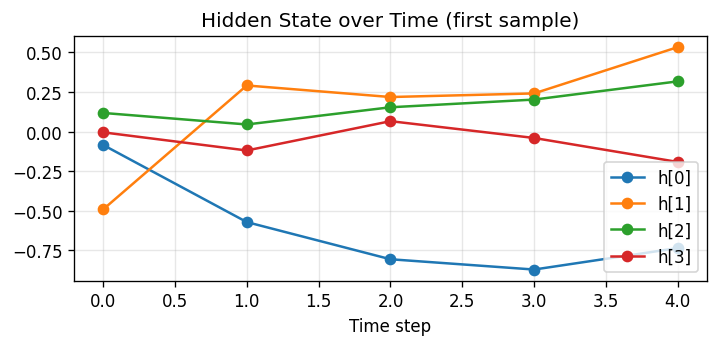

In [3]:
rnn = nn.RNN(input_size=len(chars), hidden_size=8, batch_first=True)
output, h_n = rnn(encoded)

print("output shape:", tuple(output.shape))  # batch, seq_len, hidden_size
print("h_n shape   :", tuple(h_n.shape))    # num_layers, batch, hidden_size
print("last hidden state of first sample:")
print(output[0])

plt.figure(figsize=(6, 3))
for i in range(4):
    plt.plot(output[0, :, i].detach().numpy(), marker="o", label=f"h[{i}]")
plt.title("Hidden State over Time (first sample)")
plt.xlabel("Time step")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. 문자 시퀀스 분류 모델

문자열 하나를 보고 class 하나를 예측하므로 many-to-one 구조이다. 마지막 hidden state `h_n[-1]`을 fully connected layer에 넣어 분류한다.

In [4]:
def make_loader(encoded_tensor, label_tensor, batch_size=4, seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)
    dataset = TensorDataset(encoded_tensor, label_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)


class CharRNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits


def train_classifier(model, encoded_tensor, label_tensor, epochs=80, lr=1e-2, batch_size=4):
    model = model.to(device)
    encoded_tensor = encoded_tensor.to(device)
    label_tensor = label_tensor.to(device)

    train_loader = make_loader(encoded_tensor, label_tensor, batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += xb.size(0)

        loss_history.append(total_loss / total_count)
        acc_history.append(total_correct / total_count)

    return loss_history, acc_history


def evaluate_classifier(model, encoded_tensor, label_tensor, sample_list):
    model.eval()
    with torch.no_grad():
        logits = model(encoded_tensor.to(device))
        preds = logits.argmax(dim=1).cpu()

    for s, target, pred in zip(sample_list, label_tensor.tolist(), preds.tolist()):
        print(f"{s:>8s} -> target={target}, pred={pred}")


torch.manual_seed(SEED)
model = CharRNNClassifier(input_dim=len(chars), hidden_dim=16, num_classes=2)
print(model)

loss_history, acc_history = train_classifier(model, encoded, y, epochs=80)
print("final loss:", round(loss_history[-1], 4))
print("final acc :", round(acc_history[-1], 4))

CharRNNClassifier(
  (rnn): RNN(9, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=2, bias=True)
)


final loss: 0.0003
final acc : 1.0


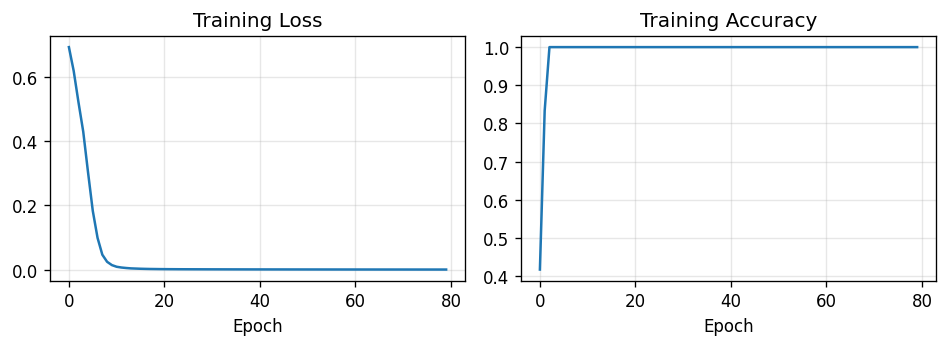

   aeiio -> target=1, pred=1
   aeexo -> target=1, pred=1
   ioeaa -> target=1, pred=1
   eioou -> target=1, pred=1
   bcdex -> target=0, pred=0
   bcddx -> target=0, pred=0
   ccdbb -> target=0, pred=0
   ddcbb -> target=0, pred=0
   abcio -> target=1, pred=1
   bcdae -> target=0, pred=0
   cdeio -> target=1, pred=1
   bbbai -> target=0, pred=0


In [5]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(acc_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

evaluate_classifier(model, encoded, y, samples)

## Exercise 1. hidden size를 8, 32로 바꾸고 결과 비교

hidden size가 커지면 RNN이 저장할 수 있는 상태 벡터의 차원이 커진다. 작은 데이터에서는 8도 충분히 학습되지만, 32는 표현력이 더 커져 더 빠르게 맞출 가능성이 있다. 대신 parameter 수가 늘어나고 데이터가 작으면 과적합 위험도 커진다.

hidden= 8 | params= 170 | final_loss=0.0010 | final_acc=1.0000
hidden=32 | params=1442 | final_loss=0.0001 | final_acc=1.0000


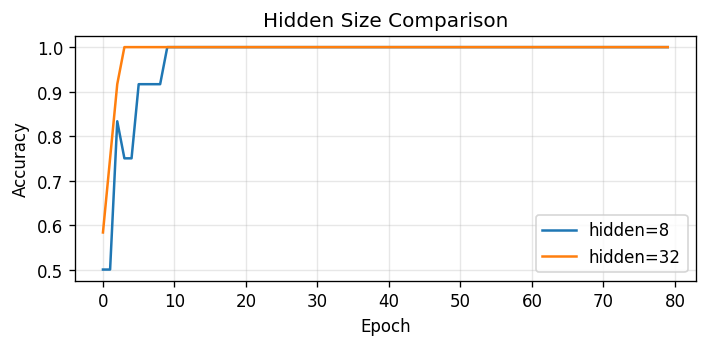

In [6]:
hidden_results = []
hidden_histories = {}

for hidden_dim in [8, 32]:
    torch.manual_seed(SEED)
    candidate = CharRNNClassifier(len(chars), hidden_dim, 2)
    losses, accs = train_classifier(candidate, encoded, y, epochs=80)
    hidden_results.append(
        {
            "hidden_dim": hidden_dim,
            "final_loss": losses[-1],
            "final_acc": accs[-1],
            "parameters": sum(p.numel() for p in candidate.parameters()),
        }
    )
    hidden_histories[hidden_dim] = (losses, accs)

for row in hidden_results:
    print(
        f"hidden={row['hidden_dim']:>2d} | "
        f"params={row['parameters']:>4d} | "
        f"final_loss={row['final_loss']:.4f} | "
        f"final_acc={row['final_acc']:.4f}"
    )

plt.figure(figsize=(6, 3))
for hidden_dim, (_, accs) in hidden_histories.items():
    plt.plot(accs, label=f"hidden={hidden_dim}")
plt.title("Hidden Size Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 2. 문자 집합에 새로운 문자를 추가하고 데이터 다시 만들기

문자 `z`를 새로 추가했다. one-hot vector는 문자 종류 수만큼 차원이 필요하므로 입력 차원은 9에서 10으로 증가한다.

In [7]:
extended_chars = list("abcdexiouz")
extended_samples = [
    "aeiio", "aeexo", "ioeaa", "eioou",
    "bcdex", "bcddx", "ccdbb", "ddcbb",
    "abcio", "bcdae", "cdeio", "bbbai",
    "zzzza", "azzzz", "eiozz", "aeizz",
]

extended_encoded, extended_y = make_dataset(extended_samples, extended_chars)
print("old input dim:", len(chars))
print("new input dim:", len(extended_chars))
print("extended encoded shape:", tuple(extended_encoded.shape))
print("extended labels:", extended_y.tolist())

torch.manual_seed(SEED)
extended_model = CharRNNClassifier(len(extended_chars), 16, 2)
extended_losses, extended_accs = train_classifier(extended_model, extended_encoded, extended_y, epochs=100)
print("extended final loss:", round(extended_losses[-1], 4))
print("extended final acc :", round(extended_accs[-1], 4))
evaluate_classifier(extended_model, extended_encoded, extended_y, extended_samples)

old input dim: 9
new input dim: 10
extended encoded shape: (16, 5, 10)
extended labels: [1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]


extended final loss: 0.0002
extended final acc : 1.0
   aeiio -> target=1, pred=1
   aeexo -> target=1, pred=1
   ioeaa -> target=1, pred=1
   eioou -> target=1, pred=1
   bcdex -> target=0, pred=0
   bcddx -> target=0, pred=0
   ccdbb -> target=0, pred=0
   ddcbb -> target=0, pred=0
   abcio -> target=1, pred=1
   bcdae -> target=0, pred=0
   cdeio -> target=1, pred=1
   bbbai -> target=0, pred=0
   zzzza -> target=0, pred=0
   azzzz -> target=0, pred=0
   eiozz -> target=1, pred=1
   aeizz -> target=1, pred=1


## Exercise 3. 시퀀스 길이를 더 길게 만들고 학습 변화 확인

시퀀스가 길어지면 RNN이 더 많은 time step을 지나야 한다. 이론적으로는 먼 과거 정보가 약해질 수 있어 학습이 어려워질 수 있지만, 이 예제처럼 규칙이 단순하고 데이터가 작으면 충분히 학습된다.

short sequence shape: (12, 5, 9)
long sequence shape : (12, 10, 9)


short final loss/acc: 0.0003 1.0
long final loss/acc : 0.0003 1.0


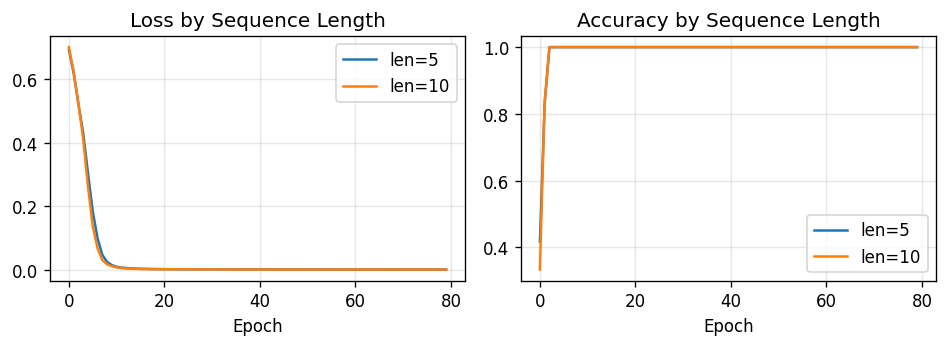

In [8]:
long_samples = [
    "aeiioaeiou", "aeexoaeiou", "ioeaauaeio", "eioouaaeio",
    "bcdexbcddx", "bcddxbcdex", "ccdbbddcbb", "ddcbbccdbb",
    "abcioabcio", "bcdaebcdae", "cdeiocdeio", "bbbaibbbai",
]

long_encoded, long_y = make_dataset(long_samples, chars)
print("short sequence shape:", tuple(encoded.shape))
print("long sequence shape :", tuple(long_encoded.shape))

torch.manual_seed(SEED)
short_model = CharRNNClassifier(len(chars), 16, 2)
short_losses, short_accs = train_classifier(short_model, encoded, y, epochs=80)

torch.manual_seed(SEED)
long_model = CharRNNClassifier(len(chars), 16, 2)
long_losses, long_accs = train_classifier(long_model, long_encoded, long_y, epochs=80)

print("short final loss/acc:", round(short_losses[-1], 4), round(short_accs[-1], 4))
print("long final loss/acc :", round(long_losses[-1], 4), round(long_accs[-1], 4))

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(short_losses, label="len=5")
plt.plot(long_losses, label="len=10")
plt.title("Loss by Sequence Length")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(short_accs, label="len=5")
plt.plot(long_accs, label="len=10")
plt.title("Accuracy by Sequence Length")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 4. `nn.RNN`을 `nn.GRU`로 변경

GRU도 `output, h_n`을 반환하므로 기본 RNN과 forward 구조가 거의 같다. 바뀌는 핵심은 `self.rnn = nn.RNN(...)`을 `self.gru = nn.GRU(...)`로 바꾸는 부분이다.

RNN final loss/acc: 0.0003 1.0
GRU final loss/acc: 0.0002 1.0


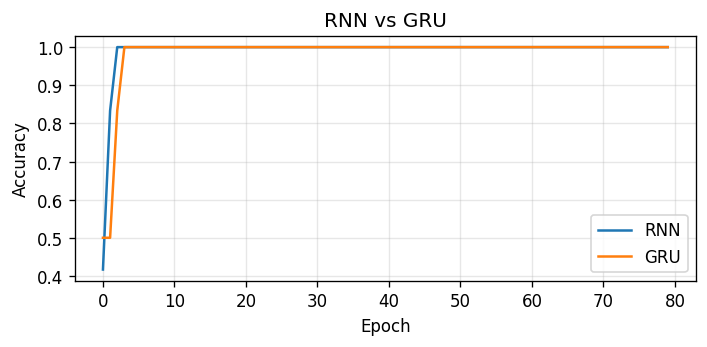

In [9]:
class CharGRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        output, h_n = self.gru(x)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits


torch.manual_seed(SEED)
rnn_compare_model = CharRNNClassifier(len(chars), 16, 2)
rnn_losses, rnn_accs = train_classifier(rnn_compare_model, encoded, y, epochs=80)

torch.manual_seed(SEED)
gru_model = CharGRUClassifier(len(chars), 16, 2)
gru_losses, gru_accs = train_classifier(gru_model, encoded, y, epochs=80)

print("RNN final loss/acc:", round(rnn_losses[-1], 4), round(rnn_accs[-1], 4))
print("GRU final loss/acc:", round(gru_losses[-1], 4), round(gru_accs[-1], 4))

plt.figure(figsize=(6, 3))
plt.plot(rnn_accs, label="RNN")
plt.plot(gru_accs, label="GRU")
plt.title("RNN vs GRU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 5. many-to-one 대신 many-to-many가 필요한 경우

현재 실습은 문자열 하나에 class 하나를 붙이는 many-to-one 문제이다. 반대로 각 time step마다 출력이 필요하거나, 입력 sequence에 대응되는 출력 sequence가 필요하면 many-to-many 구조가 필요하다.

예시는 다음과 같다.

- 품사 태깅: 문장 안의 각 단어마다 명사, 동사, 형용사 같은 품사를 예측한다.
- 개체명 인식: 각 단어가 사람 이름, 장소, 기관인지 표시한다.
- 다음 문자 예측: 매 시점마다 다음 문자를 예측해 문장을 생성한다.
- 프레임별 행동 인식: 영상의 각 프레임마다 동작 label을 예측한다.

따라서 출력 label이 sequence 전체에 하나면 many-to-one, time step마다 필요하면 many-to-many를 사용한다.